# 04 — Recovery: NDVI by severity class, 2025–2026 growing seasons

Monthly (Jun–Sep) median NDVI composites built with the same SCL keep-list, offset correction and 20 m grid as 01, grouped by the FIREMON classes from 02 (pre-fire NDVI ≥ 0.10 mask, Decision Log 2026-10-08). The control is unburned vegetation in the 2 km ring outside the perimeter (dNBR < 0.10).

- **Caveat:** severity classes come from the Jul–Aug 2025 image, so 2025 NDVI by class is not independent of the classification. The **2025 → 2026 change** is the recovery signal.
- **Not yet masked:** the Jasper townsite (open decision, no published boundary found).

Outputs: `data/ndvi_monthly_2025_2026.tif` (Drive), `figures/recovery_*.csv`, `figures/recovery_ndvi_by_class.png`.

In [1]:
![ -d /content/jasper-burn-severity ] || git clone https://github.com/MegaDeadCowboy/jasper-burn-severity.git /content/jasper-burn-severity
%cd /content/jasper-burn-severity
!pip install -q pystac-client planetary-computer stackstac rioxarray geopandas
import logging; logging.getLogger("rasterio._env").setLevel(logging.ERROR)

Cloning into '/content/jasper-burn-severity'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 75 (delta 36), reused 25 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 4.44 MiB | 9.68 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/jasper-burn-severity
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.2 MB/s eta 0:00:00


In [4]:
import sys; sys.path.insert(0, ".")
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd, xarray as xr, rioxarray
from rasterio.features import rasterize
import pystac_client, planetary_computer, stackstac
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from src.indices import ndvi, SEVERITY_LABELS
from google.colab import drive; drive.mount("/content/drive")

DATA = Path("/content/drive/MyDrive/jasper-burn-severity/data")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
UTM, RES, PIX_HA, BUFFER_M = 32611, 20, 0.04, 2000
BURN_T = 0.10                                  # dNBR >= this = burned (FIREMON Low lower bound)
VEG_T = 0.10                                   # pre-fire NDVI mask (Decision Log 2026-10-08)
SCL_KEEP = [2, 4, 5, 6, 7]                     # same keep-list as 01
MAX_ZERO_PCT = 5.0                             # drop a month if > this % of perimeter pixels have no clear obs
MONTHS = [f"{y}-{m:02d}" for y in (2025, 2026) for m in (6, 7, 8, 9)]
for f in ["severity_2023_2025.tif", "dnbr_2023_2025.tif", "s2_pre_2023.tif", "nbac_jasper_2024.gpkg"]:
    assert (DATA / f).exists(), f"missing {f}: run 01 and 02 first"

sev = rioxarray.open_rasterio(DATA / "severity_2023_2025.tif", masked=True).squeeze("band", drop=True)
dnbr = rioxarray.open_rasterio(DATA / "dnbr_2023_2025.tif", masked=True).squeeze("band", drop=True).values
pre = rioxarray.open_rasterio(DATA / "s2_pre_2023.tif", masked=True).assign_coords(
    band=["B04", "B08", "B8A", "B12"]).to_dataset("band")
ndvi_pre = ndvi(pre).values
perim = gpd.read_file(DATA / "nbac_jasper_2024.gpkg").to_crs(UTM)
shape, transform = sev.shape, sev.rio.transform()
bounds = tuple(perim.buffer(BUFFER_M).total_bounds)   # same bounds 01 passed to stackstac
assert dnbr.shape == shape == ndvi_pre.shape, "02 outputs are not on one grid"

def burn(geoms):
    return rasterize(((g, 1) for g in geoms), out_shape=shape, transform=transform,
                     fill=0, dtype="uint8").astype(bool)

in_perim = burn(perim.geometry)                # NBAC islands are holes -> False, as in 03
in_aoi = burn(perim.buffer(BUFFER_M))
aoi_ll = perim.buffer(BUFFER_M).to_crs(4326).iloc[0]
print(dict(sev.sizes), "| perimeter px:", f"{in_perim.sum():,}", "| AOI px:", f"{in_aoi.sum():,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{'y': 2257, 'x': 1308} | perimeter px: 790,558 | AOI px: 1,515,242


## 1. Scene availability and clear observations per month
Search each month, then count clear SCL observations per pixel inside the perimeter. A month is used only if it has scenes and ≤ `MAX_ZERO_PCT` % of perimeter pixels with zero clear observations. The stack call is the same as in 01, so the grid matches 02 pixel for pixel; the assert checks it.

In [5]:
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1",
                                    modifier=planetary_computer.sign_inplace)

def month_range(ym):
    p = pd.Period(ym, "M")
    return f"{p.start_time:%Y-%m-%d}/{p.end_time:%Y-%m-%d}"

def stack(its, assets):
    da = stackstac.stack(its, assets=assets, epsg=UTM, resolution=RES, bounds=bounds,
                         dtype="float32", fill_value=np.float32(np.nan), rescale=False, chunksize=1024)
    assert (da.sizes["y"], da.sizes["x"]) == shape, f"grid mismatch: {da.sizes} vs {shape}"
    dx, dy = float(da.x[0] - sev.x[0]), float(da.y[0] - sev.y[0])
    assert abs(dx) <= RES / 2 and abs(dy) <= RES / 2, f"grid offset {dx}, {dy} m"
    return da

items, rows = {}, []
for ym in MONTHS:
    its = catalog.search(collections=["sentinel-2-l2a"], intersects=aoi_ll, datetime=month_range(ym),
                         query={"eo:cloud_cover": {"lt": 60}}).item_collection()
    items[ym] = its
    clear = np.zeros(shape, "int64")
    if len(its):
        scl = stack(its, ["SCL"]).sel(band="SCL")
        clear = scl.isin(SCL_KEEP).sum("time").compute().values
    c = clear[in_perim]
    rows.append({"month": ym, "scenes": len(its),
                 "tiles": ",".join(sorted({i.properties["s2:mgrs_tile"] for i in its})),
                 "clear_min": int(c.min()), "clear_median": float(np.median(c)),
                 "pct_zero_clear": round(100 * (c == 0).mean(), 2)})
avail = pd.DataFrame(rows).set_index("month")
avail["use"] = (avail.scenes > 0) & (avail.pct_zero_clear <= MAX_ZERO_PCT)
use_months = list(avail.index[avail.use])
assert use_months, "no usable month: relax MAX_ZERO_PCT or cloud filter"
print("grid offset vs 02 (m):", float(stack(items[use_months[0]], ["SCL"]).x[0] - sev.x[0]))
print("dropped:", [m for m in MONTHS if m not in use_months] or "none")
avail

grid offset vs 02 (m): 0.0
dropped: ['2026-06']


,scenes,tiles,clear_min,clear_median,pct_zero_clear,use
month,,,,,,
2025-06,4,11UMU,0,3.0,0.02,True
2025-07,7,11UMU,3,6.0,0.00,True
2025-08,9,11UMU,4,9.0,0.00,True
2025-09,6,11UMU,2,5.0,0.00,True
2026-06,2,11UMU,0,1.0,16.30,False
2026-07,8,11UMU,2,5.0,0.00,True
2026-08,11,11UMU,4,9.0,0.00,True
2026-09,7,11UMU,2,6.0,0.00,True


## 2. Monthly NDVI composites
Median B04 and B08 per month (SCL-masked, baseline ≥ 04.00 offset removed, clipped to [0, 1]), then NDVI. Composites are computed one month at a time to stay Colab-safe.

In [6]:
%%time
def month_ndvi(its):
    da = stack(its, ["B04", "B08", "SCL"])
    scl = da.sel(band="SCL")
    offset = xr.where(da["s2:processing_baseline"].astype(float) >= 4.0, 1000.0, 0.0).astype("float32")
    refl = ((da.sel(band=["B04", "B08"]) - offset) / 10000.0).where(scl.isin(SCL_KEEP)).clip(0, 1)
    med = refl.median("time", skipna=True).compute()
    b4, b8 = med.sel(band="B04").values, med.sel(band="B08").values
    return ((b8 - b4) / (b8 + b4)).astype("float32")

ndvi_m = {}
for ym in use_months:
    ndvi_m[ym] = month_ndvi(items[ym])
    print(ym, f"median NDVI inside perimeter: {np.nanmedian(ndvi_m[ym][in_perim]):.3f}")

ndvi_stack = xr.DataArray(np.stack([ndvi_m[m] for m in use_months]), dims=("month", "y", "x"),
                          coords={"month": use_months, "y": sev.y, "x": sev.x}).rio.write_crs(UTM)

/usr/local/lib/python3.13/dist-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
<timed exec>:8: RuntimeWarning: invalid value encountered in divide


2025-06 median NDVI inside perimeter: 0.208


/usr/local/lib/python3.13/dist-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
<timed exec>:8: RuntimeWarning: invalid value encountered in divide


2025-07 median NDVI inside perimeter: 0.269


/usr/local/lib/python3.13/dist-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


...

/usr/local/lib/python3.13/dist-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
<timed exec>:8: RuntimeWarning: invalid value encountered in divide


2026-08 median NDVI inside perimeter: 0.411


/usr/local/lib/python3.13/dist-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


2026-09 median NDVI inside perimeter: 0.414
CPU times: user 4min 8s, sys: 6.23 s, total: 4min 15s
Wall time: 10min 4s


<timed exec>:8: RuntimeWarning: invalid value encountered in divide


## 3. Zones
Severity classes inside the perimeter on vegetated pixels (pre-fire NDVI ≥ 0.10), plus the unburned control ring. Stats use only pixels with a valid NDVI in **every** used month and in the pre-fire composite, so each month is computed over the same pixels.

In [7]:
veg = ndvi_pre >= VEG_T
sev_v = sev.values
common = np.isfinite(ndvi_stack.values).all(axis=0) & np.isfinite(ndvi_pre)

CONTROL = "Control (2 km ring, unburned)"
zones = {lab: in_perim & veg & (sev_v == k) for k, lab in enumerate(SEVERITY_LABELS)}
zones[CONTROL] = in_aoi & ~in_perim & veg & (dnbr < BURN_T)

zone_tbl = pd.DataFrame({z: {"pixels": int(m.sum()), "pixels_common": int((m & common).sum())}
                         for z, m in zones.items()}).T
zone_tbl["ha_common"] = (zone_tbl.pixels_common * PIX_HA).round(1)
zone_tbl["pct_kept"] = (100 * zone_tbl.pixels_common / zone_tbl.pixels).round(1)
zone_tbl

,pixels,pixels_common,ha_common,pct_kept
Unburned,22514,22427,897.1,99.6
Low,63166,63113,2524.5,99.9
Moderate-low,166453,166436,6657.4,100.0
Moderate-high,339015,339011,13560.4,100.0
High,195574,195567,7822.7,100.0
"Control (2 km ring, unburned)",579425,547694,21907.8,94.5


## 4. NDVI by class and month
- `ndvi_median`: median NDVI over the zone's common pixels.
- `ratio_to_pre`: `ndvi_median` / the zone's pre-fire (Jul–Aug 2023) median.
- `dndvi_vs_control`: (zone change from pre-fire) − (control change from pre-fire) for the same month. This removes phenology and year-to-year differences that the control shares.

In [8]:
PRE_LABEL = "2023 pre-fire"
rows = []
for z, m in zones.items():
    mm = m & common
    base = float(np.median(ndvi_pre[mm]))
    rows.append({"zone": z, "month": PRE_LABEL, "ndvi_median": base, "pixels": int(mm.sum())})
    for i, ym in enumerate(use_months):
        rows.append({"zone": z, "month": ym, "ndvi_median": float(np.median(ndvi_stack.values[i][mm])),
                     "pixels": int(mm.sum())})
long = pd.DataFrame(rows)
pre_med = long[long.month == PRE_LABEL].set_index("zone").ndvi_median
long["ratio_to_pre"] = long.ndvi_median / long.zone.map(pre_med)
chg = long.ndvi_median - long.zone.map(pre_med)
ctrl_chg = long.month.map((chg[long.zone == CONTROL]).set_axis(long.month[long.zone == CONTROL]))
long["dndvi_vs_control"] = chg - ctrl_chg

wide = long.pivot(index="zone", columns="month", values="ndvi_median").loc[list(zones), [PRE_LABEL] + use_months]
wide.round(3)

month,2023 pre-fire,2025-06,2025-07,2025-08,2025-09,2026-07,2026-08,2026-09
zone,,,,,,,,
Unburned,0.479,0.411,0.485,0.515,0.446,0.516,0.501,0.483
Low,0.547,0.339,0.438,0.494,0.429,0.521,0.499,0.466
Moderate-low,0.573,0.247,0.338,0.422,0.382,0.470,0.444,0.426
Moderate-high,0.592,0.207,0.271,0.374,0.346,0.430,0.405,0.408
High,0.626,0.181,0.212,0.284,0.253,0.387,0.384,0.406
"Control (2 km ring, unburned)",0.590,0.642,0.682,0.683,0.558,0.671,0.672,0.675


**Year-over-year recovery.** Mean of the months available in **both** 2025 and 2026 (from Jul–Aug if possible, the peak-greenness window), per zone, and the 2025 → 2026 change net of the control's change.

In [9]:
both = [m for m in ("07", "08") if f"2025-{m}" in use_months and f"2026-{m}" in use_months] \
       or sorted({m[5:] for m in use_months if m.startswith("2025")} & {m[5:] for m in use_months if m.startswith("2026")})
assert both, "no month is available in both years"
print("YoY window months:", both)

yoy = pd.DataFrame({
    "ndvi_pre": pre_med,
    "ndvi_2025": wide[[f"2025-{m}" for m in both]].mean(axis=1),
    "ndvi_2026": wide[[f"2026-{m}" for m in both]].mean(axis=1),
}).loc[list(zones)]
yoy["change_2025_2026"] = yoy.ndvi_2026 - yoy.ndvi_2025
yoy["change_vs_control"] = yoy.change_2025_2026 - yoy.loc[CONTROL, "change_2025_2026"]
yoy["pct_of_pre_2026"] = 100 * yoy.ndvi_2026 / yoy.ndvi_pre
yoy.round(3)

YoY window months: ['07', '08']


,ndvi_pre,ndvi_2025,ndvi_2026,change_2025_2026,change_vs_control,pct_of_pre_2026
zone,,,,,,
Unburned,0.479,0.500,0.509,0.008,0.019,106.197
Low,0.547,0.466,0.510,0.044,0.055,93.309
Moderate-low,0.573,0.380,0.457,0.077,0.088,79.681
Moderate-high,0.592,0.322,0.418,0.095,0.106,70.488
High,0.626,0.248,0.385,0.137,0.148,61.595
"Control (2 km ring, unburned)",0.590,0.682,0.672,-0.011,0.000,113.888


## 5. Recovery chart
One line per burned class plus the control; the pre-fire level is the marker at the left. Lines break over winter. Severity colours are the same validated ordinal ramp as the 02 map; the control is neutral gray.

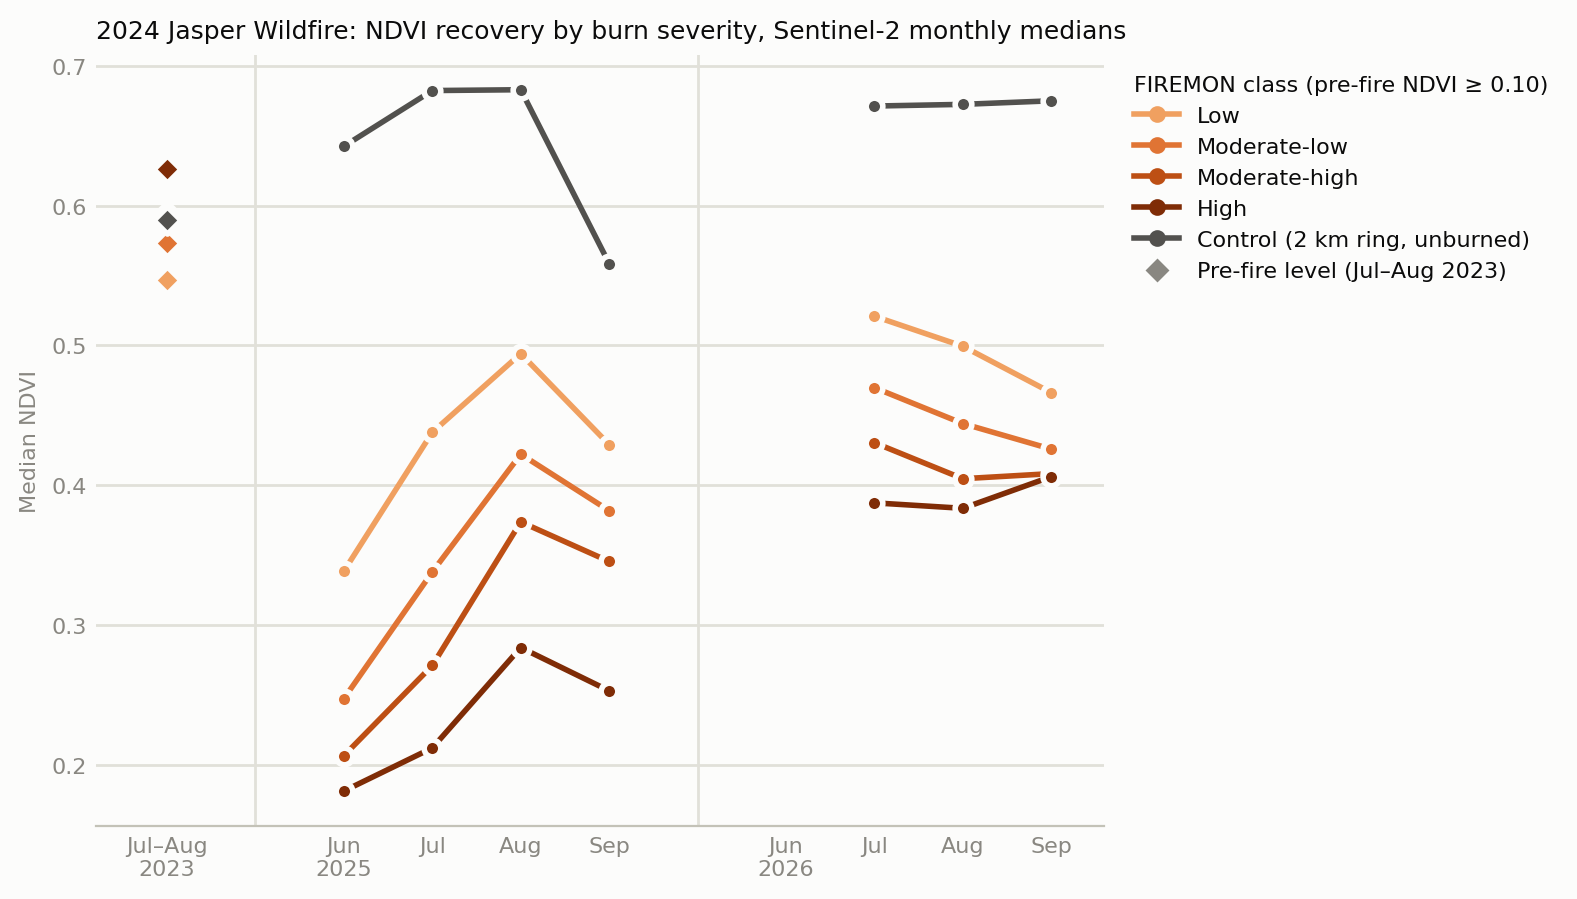

In [10]:
SEV_COLORS = ["#f0a060", "#e07434", "#bd4f14", "#7f2c06"]          # Low -> High, as in 02
SERIES = dict(zip(SEVERITY_LABELS[1:], SEV_COLORS)) | {CONTROL: "#52514e"}
INK, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
MON = {"06": "Jun", "07": "Jul", "08": "Aug", "09": "Sep"}

xpos = {PRE_LABEL: 0} | {f"{y}-{m}": (2 if y == 2025 else 7) + i
                         for y in (2025, 2026) for i, m in enumerate(MON)}
fig, ax = plt.subplots(figsize=(8, 4.6), dpi=200)
fig.patch.set_facecolor(SURF); ax.set_facecolor(SURF)
for z, c in SERIES.items():
    s = long[long.zone == z].set_index("month").ndvi_median
    for yr in ("2025", "2026"):
        ms = [f"{yr}-{m}" for m in MON]
        ax.plot([xpos[m] for m in ms], [s.get(m, np.nan) for m in ms], color=c, lw=2,
                solid_joinstyle="round", solid_capstyle="round", zorder=2)
        ax.scatter([xpos[m] for m in ms], [s.get(m, np.nan) for m in ms], s=36, color=c,
                   edgecolors=SURF, linewidths=2, zorder=3)
    ax.scatter([0], [s[PRE_LABEL]], s=48, color=c, marker="D", edgecolors=SURF, linewidths=2, zorder=3)

ticks = [PRE_LABEL] + [f"{y}-{m}" for y in (2025, 2026) for m in MON]
ax.set_xticks([xpos[t] for t in ticks],
              ["Jul–Aug\n2023"] + [f"{MON[t[5:]]}\n{t[:4]}" if t[5:] == "06" else MON[t[5:]] for t in ticks[1:]])
ax.set_xlim(-0.8, 10.6)
ax.set_ylabel("Median NDVI", color=MUTED, fontsize=8)
ax.grid(axis="y", color=GRID, lw=1); ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(colors=MUTED, labelsize=8, length=0)
ax.axvline(1, color=GRID, lw=1); ax.axvline(6, color=GRID, lw=1)

handles = [Line2D([0], [0], color=c, lw=2, marker="o", markersize=5, label=z) for z, c in SERIES.items()]
handles.append(Line2D([0], [0], color=MUTED, lw=0, marker="D", markersize=5, label="Pre-fire level (Jul–Aug 2023)"))
leg = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=8,
                title="FIREMON class (pre-fire NDVI ≥ 0.10)", title_fontsize=8, labelcolor=INK)
leg.get_title().set_color(INK); leg._legend_box.align = "left"
ax.set_title("2024 Jasper Wildfire: NDVI recovery by burn severity, Sentinel-2 monthly medians",
             fontsize=9, loc="left", color=INK)
plt.tight_layout()
plt.savefig(FIG / "recovery_ndvi_by_class.png", bbox_inches="tight", facecolor=SURF)

## 6. Save

In [11]:
out = ndvi_stack.rename(month="band").assign_coords(band=np.arange(1, len(use_months) + 1))
out.attrs["long_name"] = tuple(use_months)
out.rio.to_raster(DATA / "ndvi_monthly_2025_2026.tif", compress="deflate")
avail.to_csv(FIG / "recovery_availability.csv")
zone_tbl.to_csv(FIG / "recovery_zones.csv")
long.round(4).to_csv(FIG / "recovery_ndvi_by_class.csv", index=False)
yoy.round(4).to_csv(FIG / "recovery_yoy.csv")
print("saved")

saved
